In [1]:
from sklearn.datasets import fetch_20newsgroups
full_data=fetch_20newsgroups(subset="all",remove=('headers','footers','quotes'))

In [2]:
full_data.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [3]:
selected_categories = [
    "comp.graphics",
    "comp.os.ms-windows.misc",
    'alt.atheism',
    "rec.autos",
    "rec.motorcycles",
    "rec.sport.baseball",
    'soc.religion.christian',
    'talk.politics.mideast',
    "sci.med",
    "sci.space"
]

data = fetch_20newsgroups(subset="all", categories=selected_categories,
                          remove=("headers", "footers", "quotes"))

In [4]:
data.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.mideast']

In [18]:
unique, counts = np.unique(data.target, return_counts=True)

# Print topic name with count
for idx, count in zip(unique, counts):
    print(f"{data.target_names[idx]}: {count} documents")

alt.atheism: 799 documents
comp.graphics: 973 documents
comp.os.ms-windows.misc: 985 documents
rec.autos: 990 documents
rec.motorcycles: 996 documents
rec.sport.baseball: 994 documents
sci.med: 990 documents
sci.space: 987 documents
soc.religion.christian: 997 documents
talk.politics.mideast: 940 documents


In [21]:
np.unique(data.target, return_counts=True)


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int64),
 array([799, 973, 985, 990, 996, 994, 990, 987, 997, 940], dtype=int64))

In [20]:
counts

array([799, 973, 985, 990, 996, 994, 990, 987, 997, 940], dtype=int64)

In [5]:
texts = data.data
labels_true = data.target
label_names = data.target_names
print(f"Loaded {len(texts)} docs from {len(label_names)} categories")

Loaded 9651 docs from 10 categories


In [6]:
texts[19]

"After setting up a very large (>4 pages) table in Word for Windows\nI asked word to print it to my HP laserjet II -- worked fine at first.\nAfter much editing of the table contents (but not structure) output\nrequests now kick the LJ into manual feed mode for the document\ncontaining the table.  Other documents without tables print correctly.\n\nWhere should I look and what should I change to get the document with\nthe long table to use the paper drawer rather than kick into manual\nfeed mode? [I believe I've tried all the obvious printer manager changes\nas well as replacing the hppcl.[lp]00 files with archived versions.]\n\nThanks for any and all help.\n\nPeter"

# LDA 

In [7]:
from gensim import corpora,models
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
from nltk.stem import WordNetLemmatizer
from nltk import download
import numpy as np

download('wordnet')
download("omw-1.4")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\asuna\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\asuna\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [8]:
lemmatizer=WordNetLemmatizer()
def preprocess(text):
    tokens=simple_preprocess(text,deacc=True)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOPWORDS and len(t) >= 3]
    return tokens

In [9]:
processed_docs=[preprocess(doc) for doc in texts]

In [10]:
dictionary = corpora.Dictionary(processed_docs)
dictionary.filter_extremes(no_below=15, no_above=0.5)  # remove rare and too common words
bow_corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

In [11]:
lda_model = models.LdaModel(
    corpus=bow_corpus,
    id2word=dictionary,
    num_topics=10,            
    random_state=42,
    update_every=1,
    chunksize=1000,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

In [12]:
for idx, topic in lda_model.print_topics(-1):
    print(f"🔹 Topic {idx}: {topic}\n")

🔹 Topic 0: 0.025*"armenian" + 0.011*"muslim" + 0.010*"turkish" + 0.009*"government" + 0.008*"jew" + 0.007*"russian" + 0.007*"state" + 0.007*"war" + 0.007*"people" + 0.007*"arab"

🔹 Topic 1: 0.015*"people" + 0.011*"think" + 0.007*"believe" + 0.007*"question" + 0.007*"know" + 0.007*"like" + 0.007*"thing" + 0.007*"christian" + 0.006*"way" + 0.006*"point"

🔹 Topic 2: 0.072*"max" + 0.014*"car" + 0.012*"year" + 0.010*"like" + 0.009*"game" + 0.009*"good" + 0.008*"think" + 0.007*"bike" + 0.006*"time" + 0.005*"engine"

🔹 Topic 3: 0.015*"study" + 0.011*"book" + 0.010*"science" + 0.008*"effect" + 0.008*"group" + 0.008*"greek" + 0.008*"theory" + 0.006*"problem" + 0.006*"form" + 0.006*"term"

🔹 Topic 4: 0.024*"file" + 0.021*"image" + 0.017*"window" + 0.011*"graphic" + 0.011*"program" + 0.010*"use" + 0.009*"format" + 0.008*"ftp" + 0.008*"version" + 0.008*"jpeg"

🔹 Topic 5: 0.046*"edu" + 0.031*"com" + 0.022*"mail" + 0.019*"list" + 0.014*"post" + 0.013*"send" + 0.012*"address" + 0.011*"article" + 0.01

In [13]:
lda_model.save("lda_20news.model")
dictionary.save("lda_20news_dictionary.dict")

In [14]:
def predict_topic(text):
    tokens = preprocess(text)
    bow_vector = dictionary.doc2bow(tokens)
    topic_probs = lda_model.get_document_topics(bow_vector)

    if not topic_probs:
        return "No topic confidently assigned."

    # Sort by highest probability
    topic_probs = sorted(topic_probs, key=lambda x: x[1], reverse=True)
    top_topic_id, top_prob = topic_probs[0]
    topic_terms = lda_model.show_topic(top_topic_id, topn=5)
    top_keywords = [term for term, _ in topic_terms]

    return {
        "predicted_topic_id": top_topic_id,
        "confidence": round(top_prob, 3),
        "top_keywords": top_keywords
    }

In [15]:
t="The Apple M5 chip is a new-generation processor for Mac computers, featuring a 10-core CPU with faster multithreaded performance, a 16-core Neural Engine for AI tasks, and improved graphics. It boasts up to 15% faster multithreaded CPU performance than the M4 chip, a 30% increase in unified memory bandwidth to 153GB/s, and enhanced performance for professional applications and AI features through its Neural Engine and improved GPU"

predict_topic(t)

{'predicted_topic_id': 4,
 'confidence': 0.621,
 'top_keywords': ['file', 'image', 'window', 'graphic', 'program']}

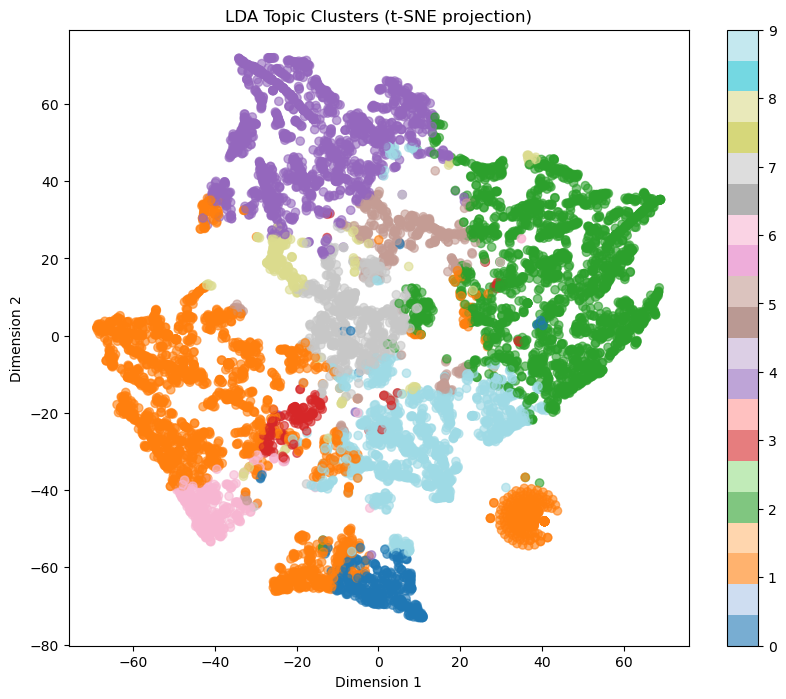

In [16]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Get document-topic distributions
doc_topics = [lda_model.get_document_topics(bow) for bow in bow_corpus]

# Convert to dense vectors
dense_doc_topics = []
for doc in doc_topics:
    dense_vec = np.zeros(lda_model.num_topics)
    for topic_id, prob in doc:
        dense_vec[topic_id] = prob
    dense_doc_topics.append(dense_vec)

dense_doc_topics = np.array(dense_doc_topics)

# Dimensionality reduction
tsne = TSNE(n_components=2, random_state=42, perplexity=50, learning_rate=200)
tsne_results = tsne.fit_transform(dense_doc_topics)

# Assign each document its dominant topic
dominant_topic = np.argmax(dense_doc_topics, axis=1)

# Plot
plt.figure(figsize=(10,8))
plt.scatter(tsne_results[:,0], tsne_results[:,1], c=dominant_topic, cmap='tab20', alpha=0.6)
plt.colorbar()
plt.title('LDA Topic Clusters (t-SNE projection)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()


In [17]:
from gensim.models import CoherenceModel

coherence_model = CoherenceModel(
    model=lda_model,
    texts=processed_docs,   # list of tokenized docs
    dictionary=dictionary,
    coherence='c_v'
)

coherence_score = coherence_model.get_coherence()
print("Coherence Score:", coherence_score)

Coherence Score: 0.624534884998962


## method for topic modelling without using berttopic but following the order of bert topic (can use bert topic instead)

In [2]:
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

from sentence_transformers import SentenceTransformer
import umap.umap_ as umap
import hdbscan

import matplotlib.pyplot as plt

In [7]:
selected_categories = [
    "comp.graphics",
    "comp.os.ms-windows.misc",
    'alt.atheism',
    "rec.autos",
    "rec.motorcycles",
    "rec.sport.baseball",
    'soc.religion.christian',
    'talk.politics.mideast',
    "sci.med",
    "sci.space"
]

data = fetch_20newsgroups(
    subset="all",
    categories=selected_categories,
    remove=("headers", "footers", "quotes")
)

documents = data["data"]
print("Number of documents:", len(documents))


Number of documents: 9651


In [8]:
df = pd.DataFrame({"text": documents})
df = df[df["text"].str.len() > 0]  # remove empty rows
documents = df["text"].tolist()
print("Documents after cleaning:", len(documents))


Documents after cleaning: 9427


In [9]:
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    documents,
    show_progress_bar=True,
    batch_size=64
)

embeddings.shape


Batches:   0%|          | 0/148 [00:00<?, ?it/s]

(9427, 384)

In [45]:
umap_model = umap.UMAP(
    n_components=10,
    n_neighbors=25,
    metric="cosine",
    random_state=42
)

umap_embeddings = umap_model.fit_transform(embeddings)
umap_embeddings.shape


c:\Users\asuna\anaconda4\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(9427, 10)

In [64]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=100,   # adjust to control #topics
    min_samples=15,
    metric="euclidean",
    prediction_data=True
)

labels = clusterer.fit_predict(umap_embeddings)
print("Unique clusters:", np.unique(labels))


c:\Users\asuna\anaconda4\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\asuna\anaconda4\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Unique clusters: [-1  0  1  2  3  4  5  6  7  8  9 10]


In [65]:
# using tfidf to extract keywords for each topic
topics = {}

for label in np.unique(labels):
    if label == -1:
        continue  # skip noise cluster
    
    docs = [documents[i] for i in range(len(documents)) if labels[i] == label]

    tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
    X = tfidf.fit_transform(docs)

    top_indices = np.argsort(X.sum(axis=0).A1)[::-1][:10]
    keywords = [tfidf.get_feature_names_out()[i] for i in top_indices]

    topics[label] = keywords




In [66]:
np.sum(labels == 5)

645

In [67]:
for label, words in topics.items():
    print(f"Topic {label}: {words}")

Topic 0: ['year', 'game', 'team', 'games', 'think', 'baseball', 'don', 'just', 'good', 'like']
Topic 1: ['don', 'know', 'like', 'just', 'msg', 'people', 'does', 'edu', 'doctor', 'time']
Topic 2: ['car', 'bike', 'just', 'like', 'don', 'know', 'good', 'new', 'think', 've']
Topic 3: ['armenian', 'armenians', 'turkish', 'people', 'turkey', 'said', 'greek', 'genocide', 'turks', 'armenia']
Topic 4: ['mail', 'list', 'thanks', 'com', 'edu', 'address', 'send', 'post', 'faq', 'know']
Topic 5: ['space', 'like', 'just', 'orbit', 'nasa', 'think', 'moon', 'launch', 'shuttle', 'don']
Topic 6: ['printer', 'fonts', 'font', 'windows', 'print', 'file', 'problem', 'use', 'thanks', 'driver']
Topic 7: ['israel', 'jews', 'israeli', 'people', 'arab', 'just', 'jewish', 'don', 'think', 'arabs']
Topic 8: ['god', 'people', 'think', 'don', 'just', 'jesus', 'believe', 'does', 'say', 'know']
Topic 9: ['thanks', 'know', 'graphics', 'card', 'image', 'does', 'files', 'windows', 'program', 'file']
Topic 10: ['windows', 

In [68]:
import gensim
from gensim import corpora
from gensim.models import CoherenceModel
import re


In [69]:
def clean_and_tokenize(doc):
    doc = doc.lower()
    doc = re.sub(r"[^a-zA-Z ]", " ", doc)
    tokens = [w for w in doc.split() if len(w) > 2]
    return tokens

tokenized_docs = [clean_and_tokenize(d) for d in documents]


In [70]:
dictionary = corpora.Dictionary(tokenized_docs)
dictionary.filter_extremes(no_below=10, no_above=0.5)  # optional but recommended
corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]


In [71]:
topic_words = [topics[label] for label in topics.keys()]


In [72]:
coherence_model = CoherenceModel(
    topics=topic_words,
    texts=tokenized_docs,
    dictionary=dictionary,
    coherence='c_v'
)

coherence_score = coherence_model.get_coherence()
coherence_score


0.5982917245546182

In [73]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

def compute_ctfidf(documents_per_topic, m, stop_words="english"):
    """
    documents_per_topic : dict {topic_id: [doc1, doc2, ...]}
    m : total number of documents
    returns: dict {topic_id: (keywords, scores)}
    """
    # Concatenate documents for each topic
    topic_ids = list(documents_per_topic.keys())
    corpus = [" ".join(documents_per_topic[t]) for t in topic_ids]

    # Bag-of-words per topic
    vectorizer = CountVectorizer(stop_words=stop_words)
    X = vectorizer.fit_transform(corpus)

    # c-TFIDF formula: tf * log(total_docs / term_docs)
    tf = X.toarray()
    df = np.clip(np.sum(tf > 0, axis=0), a_min=1, a_max=None)  # doc freq per term
    idf = np.log(m / df)

    ctfidf = tf * idf

    feature_names = vectorizer.get_feature_names_out()
    ctfidf_topics = {}

    # Convert matrix rows → topic keywords
    for idx, topic_id in enumerate(topic_ids):
        row = ctfidf[idx]
        top_indices = row.argsort()[::-1][:10]
        keywords = [feature_names[i] for i in top_indices]
        scores = row[top_indices]
        ctfidf_topics[topic_id] = (keywords, scores)

    return ctfidf_topics


In [74]:
# Group documents by cluster
documents_per_topic = {}

for label in np.unique(labels):
    if label == -1:
        continue  # skip noise

    docs = [documents[i] for i in range(len(documents)) if labels[i] == label]
    documents_per_topic[label] = docs

m = len(documents)  # total number of documents


In [75]:
ctfidf_topics = compute_ctfidf(documents_per_topic, m)


In [76]:
for topic, (words, scores) in ctfidf_topics.items():
    print(f"Topic {topic}: {words}")


Topic 0: ['year', 'game', 'team', 'don', 'think', 'good', 'games', 'baseball', 'time', 'like']
Topic 1: ['medical', 'don', 'like', 'people', 'know', 'patients', 'just', 'cancer', 'use', 'time']
Topic 2: ['car', 'bike', 'like', 'just', 'don', 'know', 'good', 'think', 'new', 'time']
Topic 3: ['armenian', 'armenians', 'turkish', 'people', 'said', 'armenia', 'turkey', 'azerbaijan', 'turks', 'genocide']
Topic 4: ['edu', 'graphics', 'mail', 'com', 'pub', 'send', 'ftp', 'list', 'available', 'health']
Topic 5: ['space', 'launch', 'nasa', 'earth', 'orbit', 'spacecraft', 'like', 'shuttle', 'mission', 'moon']
Topic 6: ['printer', 'windows', 'fonts', 'font', 'print', 'use', 'problem', 'truetype', 'bj', 'hp']
Topic 7: ['israel', 'israeli', 'jews', 'people', 'arab', 'jewish', 'just', 'like', 'arabs', 'muslims']
Topic 8: ['god', 'people', 'jesus', 'don', 'think', 'does', 'believe', 'just', 'say', 'church']
Topic 9: ['image', 'jpeg', 'file', 'images', 'gif', 'graphics', 'color', 'bit', 'use', 'files']

In [77]:
topic_words = [ctfidf_topics[t][0] for t in sorted(ctfidf_topics.keys())]

coherence_model = CoherenceModel(
    topics=topic_words,
    texts=tokenized_docs,  # from previous step
    dictionary=dictionary,
    coherence='c_v'
)

coherence_score = coherence_model.get_coherence()
print("Coherence (c_v):", coherence_score)


Coherence (c_v): 0.6817414941070464


c:\Users\asuna\anaconda4\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


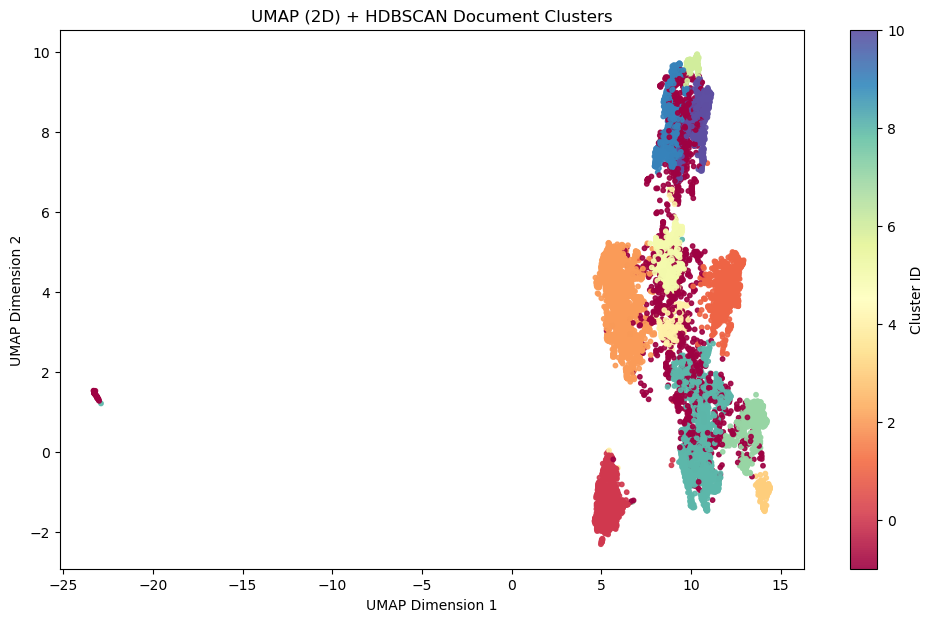

In [78]:
import matplotlib.pyplot as plt
import umap.umap_ as umap
import numpy as np

# 2D UMAP for visualization
umap_2d = umap.UMAP(
    n_components=2,
    n_neighbors=25,
    metric="cosine",
    random_state=42
).fit_transform(embeddings)

# Plot
plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    umap_2d[:, 0],
    umap_2d[:, 1],
    c=labels,
    cmap="Spectral",
    s=10,
    alpha=0.9
)

plt.colorbar(scatter, label="Cluster ID")
plt.title("UMAP (2D) + HDBSCAN Document Clusters")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()


In [83]:
new_embedding = model.encode(["A personal computer (PC) is an electronic device designed for individual use that processes, stores, and outputs data by following a set of instructions called a program. It has become a significant and ubiquitous part of modern life, used in education, business, healthcare, and communicatio"])

In [84]:
new_umap = umap_model.transform(new_embedding)


In [85]:
import hdbscan

label, strength = hdbscan.approximate_predict(clusterer, new_umap)
print("Cluster:", label[0], "Strength:", strength[0])


Cluster: 10 Strength: 0.6517355078177964


## topic classification(supervised topic modelling)

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import numpy as np
import re

In [90]:
X = data.data        # list of documents
y = data.target      # numeric labels 0–9
target_names = data.target_names

In [91]:
def preprocess_series(text_series):
    cleaned = text_series.apply(lambda x: re.sub(r"[^a-zA-Z ]", " ", x.lower()))
    cleaned = cleaned.apply(lambda x: re.sub(r"\s+", " ", x).strip())
    return cleaned


In [92]:
pipeline = Pipeline([
    ("preprocess", FunctionTransformer(preprocess_series)),
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        stop_words="english"
    )),
    ("clf", LogisticRegression(
        max_iter=300,
        n_jobs=-1,
        C=2.0
    ))
])


In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [94]:
pipeline.fit(pd.Series(X_train), y_train)


,steps,"[('preprocess', ...), ('tfidf', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function pre...001E9C69184A0>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


In [95]:
y_pred = pipeline.predict(pd.Series(X_test))

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=target_names))


Accuracy: 0.8161574313827032
                         precision    recall  f1-score   support

            alt.atheism       0.74      0.68      0.71       160
          comp.graphics       0.79      0.83      0.81       195
comp.os.ms-windows.misc       0.87      0.79      0.83       197
              rec.autos       0.64      0.85      0.73       198
        rec.motorcycles       0.82      0.78      0.80       199
     rec.sport.baseball       0.88      0.87      0.88       199
                sci.med       0.84      0.87      0.86       198
              sci.space       0.87      0.86      0.86       197
 soc.religion.christian       0.88      0.80      0.84       200
  talk.politics.mideast       0.88      0.80      0.84       188

               accuracy                           0.82      1931
              macro avg       0.82      0.81      0.82      1931
           weighted avg       0.82      0.82      0.82      1931



In [96]:
doc = "Windows 10 drivers and GPU acceleration are not working on my PC."
pred = pipeline.predict(pd.Series([doc]))[0]
print(target_names[pred])


comp.os.ms-windows.misc


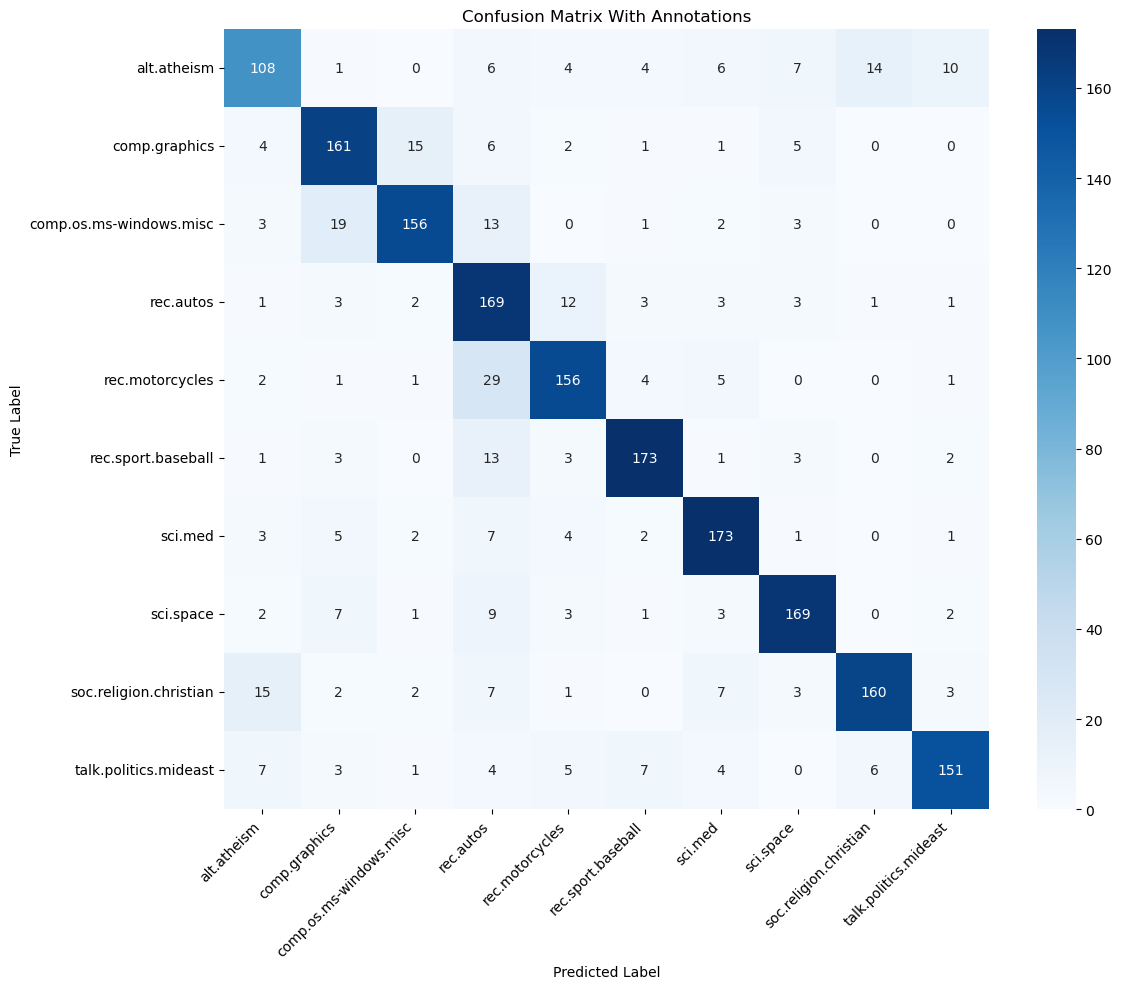

In [97]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,           # <-- annotations (numbers)
    fmt="d",              # integer formatting
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix With Annotations")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
